<a href="https://colab.research.google.com/github/franksito2019/Caso-Uso-S4/blob/main/sesion_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Frame

In [ ]:
import pandas as pd
import numpy as np

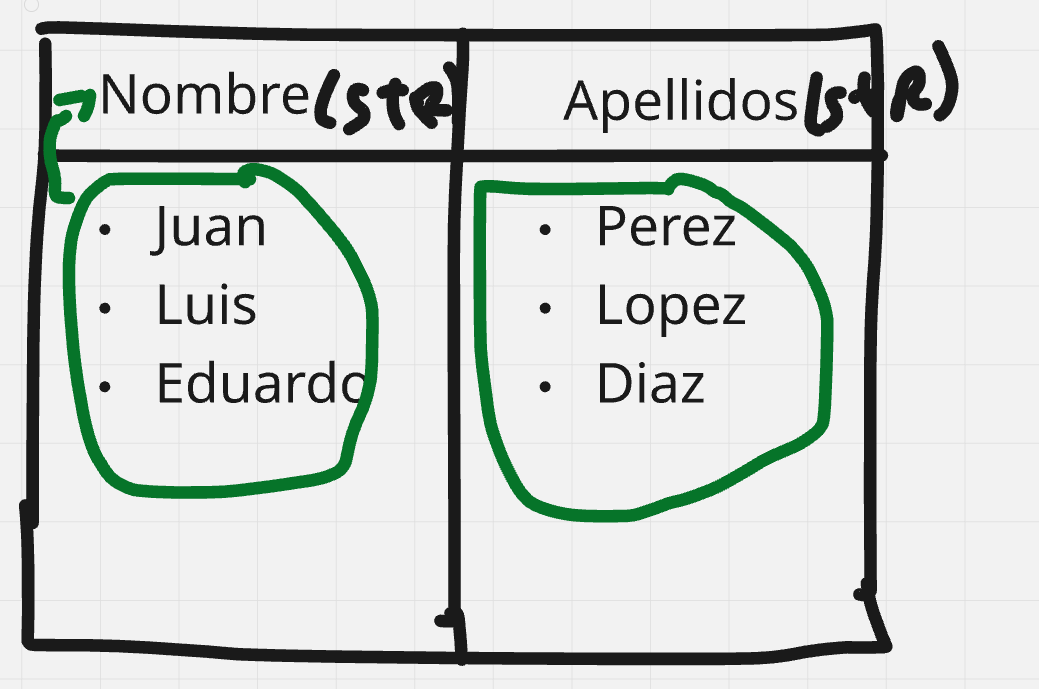

In [ ]:
lista = [123,5654,'hola mundo']
lista[1]

5654

In [ ]:
diccionario1 = {'nombre':'juan','cursos':['python','sql','C++']}
diccionario1

{'nombre': 'juan', 'cursos': ['python', 'sql', 'C++']}

In [ ]:
lista_nomb = ['Juan','Luis','Eduardo']
lista_apell = ['Perez','Lopez','Diaz']

In [ ]:
bd_alumnos = {'Nombre':lista_nomb,'Apellido':lista_apell}
bd_alumnos

{'Nombre': ['Juan', 'Luis', 'Eduardo'], 'Apellido': ['Perez', 'Lopez', 'Diaz']}

In [ ]:
tabla = pd.DataFrame(bd_alumnos)
tabla

,Nombre,Apellido
0,Juan,Perez
1,Luis,Lopez
2,Eduardo,Diaz


In [ ]:
print(tabla)

    Nombre Apellido
0     Juan    Perez
1     Luis    Lopez
2  Eduardo     Diaz


## Metodos

In [ ]:
tabla[1:2]

,Nombre,Apellido
1,Luis,Lopez


In [ ]:
tabla.loc[1]

,1
Nombre,Luis
Apellido,Lopez


In [ ]:
tabla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Nombre    3 non-null      object
 1   Apellido  3 non-null      object
dtypes: object(2)
memory usage: 180.0+ bytes


In [ ]:
tabla.shape

(3, 2)

In [ ]:
tabla.to_excel("tabla_python.xlsx",index=False)

## Ejemplo 1

Genera un programa que registre datos y notas del alumno. El programa debe consultar al docente cuantos registros va a realizar.
Los datos a almacenar son:
- nombre
- nota_practica
- nota_examen

y el programa debe de calcular su nota final. considerando que el peso de la practica es 30% y del examen 70%. Imprimir en pantalla la cantidad total de alumnos registrados y la cantidad total de aprobados y desaprobados. Exportar dicho documento a excel. Nota minima de aprobacion 14/20.

### Etapa 1:

Almacenado de datos

In [ ]:
n_reg = int(input("Ingrese la cantidad de registros:\n"))
l_nombre = []
l_pc = []
l_examen = []
for i in range(n_reg):
  nombre = input(f"Ingrese el nombre del alumno Nº {i+1}:\n")
  l_nombre.append(nombre)
  pc = input(f"Ingrese la nota de practicas de {nombre}\n")
  l_pc.append(pc)
  examen = input(f"Ingrese la nota de examen de {nombre}\n")
  l_examen.append(examen)

Ingrese la cantidad de registros:
12
Ingrese el nombre del alumno Nº 0:
Jose
Ingrese la nota de practicas de Jose
16
Ingrese la nota de examen de Jose
12
Ingrese el nombre del alumno Nº 1:
Miguel
Ingrese la nota de practicas de Miguel
13
Ingrese la nota de examen de Miguel
10
Ingrese el nombre del alumno Nº 2:
Maria
Ingrese la nota de practicas de Maria
11
Ingrese la nota de examen de Maria
13
Ingrese el nombre del alumno Nº 3:
Martin
Ingrese la nota de practicas de Martin
15
Ingrese la nota de examen de Martin
11
Ingrese el nombre del alumno Nº 4:
Luis
Ingrese la nota de practicas de Luis
12
Ingrese la nota de examen de Luis
19
Ingrese el nombre del alumno Nº 5:
Luisa
Ingrese la nota de practicas de Luisa
19
Ingrese la nota de examen de Luisa
18
Ingrese el nombre del alumno Nº 6:
Emilia
Ingrese la nota de practicas de Emilia
11
Ingrese la nota de examen de Emilia
15
Ingrese el nombre del alumno Nº 7:
Rodrigo
Ingrese la nota de practicas de Rodrigo
15
Ingrese la nota de examen de Rodri

### Etapa 2

Consolidando la tabla

In [ ]:
tabla2 = pd.DataFrame({'Nombre':l_nombre,'Nota_practica':l_pc,'Nota_examen':l_examen})
tabla2.head()

,Nombre,Nota_practica,Nota_examen
0,Jose,16,12
1,Miguel,13,10
2,Maria,11,13
3,Martin,15,11
4,Luis,12,19


In [ ]:
tabla2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nombre         12 non-null     object 
 1   Nota_practica  12 non-null     float64
 2   Nota_examen    12 non-null     float64
dtypes: float64(2), object(1)
memory usage: 420.0+ bytes


In [ ]:
# cambiar de formato
tabla2['Nota_practica'] = tabla2['Nota_practica'].astype(float)

In [ ]:
tabla2['Nota_examen'] = tabla2['Nota_examen'].astype(float)

### Etapa 3

creando columnas

In [ ]:
tabla2['Nota_final'] = tabla2['Nota_practica']*0.3 + tabla2['Nota_examen']*0.7

In [ ]:
tabla2.to_excel("tabla_alumnos.xlsx",index=False)

In [ ]:
tabla2['Resultado'] = np.where(tabla2['Nota_final']>=14,'Aprobado','Desaprobado')

In [ ]:
tabla2

,Nombre,Nota_practica,Nota_examen,Nota_final,Resultado
0,Jose,16.0,12.0,13.2,Desaprobado
1,Miguel,13.0,10.0,10.9,Desaprobado
2,Maria,11.0,13.0,12.4,Desaprobado
3,Martin,15.0,11.0,12.2,Desaprobado
4,Luis,12.0,19.0,16.9,Aprobado
5,Luisa,19.0,18.0,18.3,Aprobado
6,Emilia,11.0,15.0,13.8,Desaprobado
7,Rodrigo,15.0,12.0,12.9,Desaprobado
8,Marcelo,16.0,11.0,12.5,Desaprobado
9,Enrique,16.0,12.0,13.2,Desaprobado


### Etapa 4

Numero de filas y numeros de desaprobados y aprobados.

In [ ]:
n_filas = len(tabla2)
print(f"Nº de alumnos {n_filas}")

Nº de alumnos 12


In [ ]:
n_filas_a = len(tabla2.query(" Resultado == 'Aprobado' "))

In [ ]:
n_filas_d = len(tabla2.query(" Resultado == 'Desaprobado' "))

### Etapa 5

Exportar tabla y dirigirla a carpeta

In [ ]:
print(f"Nº de alumnos aprobados {n_filas_a}")
print(f"Nº de alumnos desaprobados {n_filas_d}")
input("Encuentra el reporte en 'ReporteAlumnos.xlsx'\nENTER para cerrar...")

Nº de alumnos aprobados 4
Nº de alumnos desaprobados 8


In [ ]:
import datetime as dt

In [ ]:
dt.date.today()

datetime.date(2025, 12, 7)

In [ ]:
time = dt.datetime.now().strftime("%Y%m%d_%H%M")

fuente: [Formatos de tiempo](https://docs.python.org/3/library/datetime.html)

In [ ]:
import os

In [ ]:
#carpeta de reportes
os.makedirs("ReporteAlumnos",exist_ok=True)

In [ ]:
'ReporteAlumnos' + time

'ReporteAlumnos20251207_0154'

In [ ]:
tabla2.to_excel("ReporteAlumnos/ReporteAlumnos_"+time+".xlsx",index=False)

In [ ]:
tabla3 = pd.read_excel("tabla_python.xlsx")

In [ ]:
tabla3

,Nombre,Apellido
0,Juan,Perez
1,Luis,Lopez
2,Eduardo,Diaz
